# Multilingual & Multimodal Search with LlamaIndex
https://qdrant.tech/documentation/multimodal-search/
#
dataset:  https://github.com/qdrant/examples/tree/master/multimodal-search/images


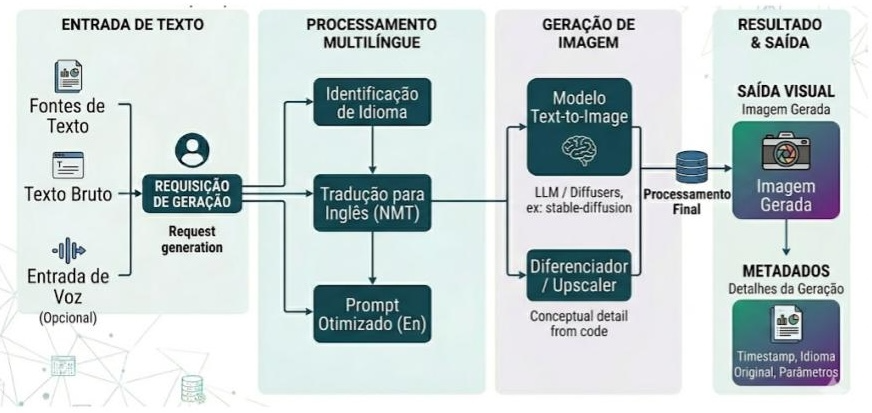

In [ ]:
#!pip install llama-index-embeddings-huggingface

In [ ]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [2]:
import torch

if not hasattr(torch.compiler, "is_compiling"): #if needed
    torch.compiler.is_compiling = lambda: False


import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" #if needed

model = HuggingFaceEmbedding(
    model_name="llamaindex/vdr-2b-multi-v1",
    device="cpu",  # "mps" for mac, "cuda" for nvidia GPUs, "cpu" for cpu
    trust_remote_code=True,
)

config_sentence_transformers.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

custom_st.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/llamaindex/vdr-2b-multi-v1:
- custom_st.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [3]:
documents = [
    {"caption": "An image about plane emergency safety.", "image": "images/image-1.png"},
    {"caption": "An image about airplane components.", "image": "images/image-2.png"},
    {"caption": "An image about COVID safety restrictions.", "image": "images/image-3.png"},
    {"caption": "An confidential image about UFO sightings.", "image": "images/image-4.png"},
    {"caption": "An image about unusual footprints on Aralar 2011.", "image": "images/image-5.png"},
]

text_embeddings = model.get_text_embedding_batch([doc["caption"] for doc in documents])
image_embeddings = model.get_image_embedding_batch([doc["image"] for doc in documents])

## Upload data to Qdrant

In [4]:
from qdrant_client import QdrantClient, models

# docker run -p 6333:6333 qdrant/qdrant
client = QdrantClient(url="http://localhost:6333/")

In [5]:
COLLECTION_NAME = "llama-multi"

if not client.collection_exists(COLLECTION_NAME):
    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config={
            "image": models.VectorParams(size=len(image_embeddings[0]), distance=models.Distance.COSINE),
            "text": models.VectorParams(size=len(text_embeddings[0]), distance=models.Distance.COSINE),
        }
    )

In [6]:
client.upload_points(
    collection_name=COLLECTION_NAME,
    points=[
        models.PointStruct(
            id=idx,
            vector={
                "text": text_embeddings[idx],
                "image": image_embeddings[idx],
            },
            payload=doc
        )
        for idx, doc in enumerate(documents)
    ]
)

### Search
#### Text-to-Image
Let’s see what image we will get to the query “Adventures on snow hills”.

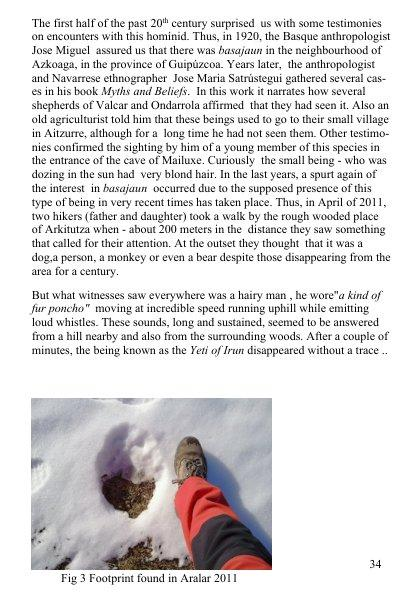

In [7]:
from PIL import Image

query_vector = model.get_text_embedding("Adventures on snow hills")

results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vector,
    using="image",
    with_payload=["image"],
    limit=1
)

Image.open(results.points[0].payload["image"])


### Multilingual Search
Now, let’s do a multilingual search using an Portuguese query:

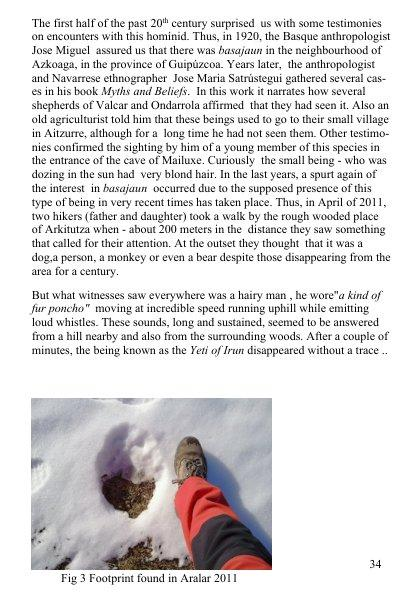

In [8]:
from PIL import Image

query_vector = model.get_text_embedding("Aventuras em colinas nevadas")

results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vector,
    using="image",
    with_payload=["image"],
    limit=1
)

Image.open(results.points[0].payload["image"])

### Image-to-Text

In [9]:
client.query_points(
    collection_name=COLLECTION_NAME,
    query=model.get_image_embedding("images/image-2.png"),  
    # Now we are searching only among text vectors with our image query
    using="text",
    with_payload=["caption"],
    limit=1
).points[0].payload['caption']

'An image about airplane components.'